In [1]:
# =========================================================
# STRETCH 01 — Matrix Multiplication
# =========================================================

import numpy as np
import time


rng = np.random.default_rng(42)

A = rng.random((200, 200))
B = rng.random((200, 200))


def matrix_multiply_loops(A, B):
    """Matrix multiplication using three nested loops."""
    rows = A.shape[0]
    cols = B.shape[1]
    inner = A.shape[1]

    result = np.zeros((rows, cols))

    for i in range(rows):
        for j in range(cols):
            for k in range(inner):
                result[i, j] += A[i, k] * B[k, j]

    return result


# Time three-loop implementation
start = time.perf_counter()

C_loop = matrix_multiply_loops(A, B)

loop_time = time.perf_counter() - start


# Time NumPy @
start = time.perf_counter()

C_numpy = A @ B

numpy_time = time.perf_counter() - start


print("Loop multiplication time:",
      f"{loop_time:.6f} seconds")

print("@ multiplication time:",
      f"{numpy_time:.6f} seconds")

print("Speed ratio:",
      f"{loop_time / numpy_time:.2f}x")

print("Results approximately equal:")
print(np.allclose(C_loop, C_numpy))

Loop multiplication time: 6.821506 seconds
@ multiplication time: 0.037465 seconds
Speed ratio: 182.08x
Results approximately equal:
True


In [2]:
# =========================================================
# STRETCH 02 — Linear Regression From Scratch
# =========================================================

rng = np.random.default_rng(42)

# Generate data
x = np.linspace(0, 10, 100)

true_slope = 3.0
true_intercept = 5.0

y = (
    true_slope * x
    + true_intercept
    + rng.normal(0, 2, size=100)
)


# ---------------------------------------------------------
# Build design matrix
# ---------------------------------------------------------

# First column = intercept
# Second column = x
X = np.column_stack([
    np.ones(x.shape),
    x
])

print("Design matrix shape:", X.shape)
# Expected: (100, 2)


# ---------------------------------------------------------
# Normal equation
# ---------------------------------------------------------

beta = np.linalg.solve(
    X.T @ X,
    X.T @ y
)

intercept_from_scratch = beta[0]
slope_from_scratch = beta[1]

print("\nFrom normal equation:")
print("Intercept:", intercept_from_scratch)
print("Slope:", slope_from_scratch)


# ---------------------------------------------------------
# Compare with np.polyfit
# ---------------------------------------------------------

polyfit_slope, polyfit_intercept = np.polyfit(x, y, 1)

print("\nFrom np.polyfit:")
print("Intercept:", polyfit_intercept)
print("Slope:", polyfit_slope)


print("\nSlope matches:")
print(np.isclose(
    slope_from_scratch,
    polyfit_slope
))

print("Intercept matches:")
print(np.isclose(
    intercept_from_scratch,
    polyfit_intercept
))

print("\nBoth coefficients match:")
print(np.allclose(
    beta,
    [polyfit_intercept, polyfit_slope]
))

Design matrix shape: (100, 2)

From normal equation:
Intercept: 5.318989144069524
Slope: 2.9160943265925514

From np.polyfit:
Intercept: 5.31898914406953
Slope: 2.9160943265925523

Slope matches:
True
Intercept matches:
True

Both coefficients match:
True


In [3]:
# =========================================================
# STRETCH 03 — Condition Number
# =========================================================

rng = np.random.default_rng(42)

# A badly-conditioned diagonal matrix
A_bad = np.diag([
    1.0,
    1e-8,
    1e-12
])

b = np.array([
    1.0,
    1.0,
    1.0
])


# Condition number
condition_number = np.linalg.cond(A_bad)

print("Badly-conditioned matrix:")
print(A_bad)

print("\nCondition number:")
print(condition_number)


# Solve original system
x_original = np.linalg.solve(A_bad, b)

print("\nOriginal solution:")
print(x_original)


# Add a tiny error to b
b_perturbed = b.copy()
b_perturbed[2] += 1e-8

x_perturbed = np.linalg.solve(
    A_bad,
    b_perturbed
)

print("\nPerturbed b:")
print(b_perturbed)

print("\nPerturbed solution:")
print(x_perturbed)


# Compare solutions
relative_change_b = (
    np.linalg.norm(b_perturbed - b)
    / np.linalg.norm(b)
)

relative_change_x = (
    np.linalg.norm(x_perturbed - x_original)
    / np.linalg.norm(x_original)
)

print("\nRelative change in b:")
print(relative_change_b)

print("\nRelative change in solution:")
print(relative_change_x)

Badly-conditioned matrix:
[[1.e+00 0.e+00 0.e+00]
 [0.e+00 1.e-08 0.e+00]
 [0.e+00 0.e+00 1.e-12]]

Condition number:
1000000000000.0

Original solution:
[1.e+00 1.e+08 1.e+12]

Perturbed b:
[1.         1.         1.00000001]

Perturbed solution:
[1.00000000e+00 1.00000000e+08 1.00000001e+12]

Relative change in b:
5.773502656807963e-09

Relative change in solution:
9.999999950000001e-09


Samples shape:
(10000, 30)

Sample means shape:
(10000,)


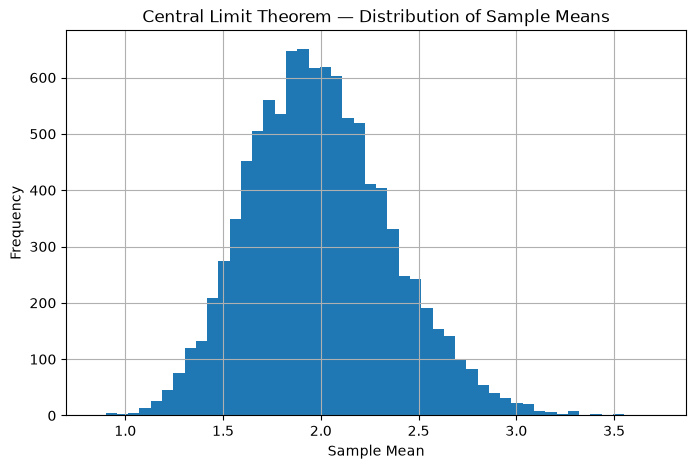

In [4]:
# =========================================================
# STRETCH 04 — Central Limit Theorem
# =========================================================

import numpy as np
import matplotlib.pyplot as plt


rng = np.random.default_rng(42)

# Number of samples
number_of_samples = 10_000

# Number of observations in each sample
sample_size = 30

# Exponential distribution is not normal
samples = rng.exponential(
    scale=2.0,
    size=(number_of_samples, sample_size)
)

print("Samples shape:")
print(samples.shape)


# Calculate the mean of every sample
sample_means = samples.mean(axis=1)

print("\nSample means shape:")
print(sample_means.shape)


# Plot distribution of sample means
plt.figure(figsize=(8, 5))

plt.hist(
    sample_means,
    bins=50
)

plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.title(
    "Central Limit Theorem — Distribution of Sample Means"
)

plt.grid(True)
plt.show()

In [6]:
# =========================================================
# STRETCH 05 — SVD and Low-Rank Reconstruction
# =========================================================

rng = np.random.default_rng(42)

# Create a matrix with some underlying structure
A = rng.normal(size=(100, 80))

print("Original matrix shape:")
print(A.shape)


# ---------------------------------------------------------
# SVD
# ---------------------------------------------------------

U, S, Vt = np.linalg.svd(A, full_matrices=False)

print("\nU shape:", U.shape)
print("S shape:", S.shape)
print("Vt shape:", Vt.shape)


# ---------------------------------------------------------
# Full reconstruction
# ---------------------------------------------------------

A_full = U @ np.diag(S) @ Vt

print("\nFull reconstruction matches original:")
print(np.allclose(A, A_full))


# ---------------------------------------------------------
# Top-k reconstruction
# ---------------------------------------------------------

def reconstruct_from_k(U, S, Vt, k):
    return (
        U[:, :k]
        @ np.diag(S[:k])
        @ Vt[:k, :]
    )


# Try several values of k
k_values = [1, 2, 5, 10, 20, 40, 60, 80]

for k in k_values:
    A_k = reconstruct_from_k(U, S, Vt, k)

    error = np.linalg.norm(A - A_k)

    relative_error = (
        error / np.linalg.norm(A)
    )

    print(
        f"k={k:2d} | "
        f"relative reconstruction error="
        f"{relative_error:.6f}"
    )
    
  
# ----------------------------------------------------------------

# ---------------------------------------------------------
# Low-rank matrix with small noise
# ---------------------------------------------------------

rng = np.random.default_rng(42)

left = rng.normal(size=(100, 5))
right = rng.normal(size=(5, 80))

A_low_rank = left @ right

# Add a small amount of noise
A_low_rank += rng.normal(
    0,
    0.05,
    size=(100, 80)
)


U, S, Vt = np.linalg.svd(
    A_low_rank,
    full_matrices=False
)


for k in [1, 2, 3, 5, 10, 20]:
    A_k = (
        U[:, :k]
        @ np.diag(S[:k])
        @ Vt[:k, :]
    )

    relative_error = (
        np.linalg.norm(A_low_rank - A_k)
        / np.linalg.norm(A_low_rank)
    )

    print(
        f"k={k:2d} | "
        f"relative error={relative_error:.6f}"
    )

Original matrix shape:
(100, 80)

U shape: (100, 80)
S shape: (80,)
Vt shape: (80, 80)

Full reconstruction matches original:
True
k= 1 | relative reconstruction error=0.977740
k= 2 | relative reconstruction error=0.956830
k= 5 | relative reconstruction error=0.898940
k=10 | relative reconstruction error=0.807484
k=20 | relative reconstruction error=0.646591
k=40 | relative reconstruction error=0.376155
k=60 | relative reconstruction error=0.163104
k=80 | relative reconstruction error=0.000000
k= 1 | relative error=0.809117
k= 2 | relative error=0.656809
k= 3 | relative error=0.501229
k= 5 | relative error=0.021696
k=10 | relative error=0.019410
k=20 | relative error=0.015424
